In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, execute, BasicAer, IBMQ
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit import *
import matplotlib.pyplot as plt
%matplotlib inline
from qiskit.visualization import plot_histogram
from qiskit.extensions import Initialize

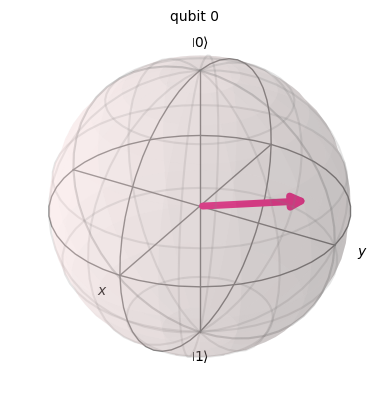

In [2]:
def random_state(nqubits):
    """Creates a random nqubit state vector"""
    from numpy import append, array, sqrt
    from numpy.random import random
    real_parts = array([])
    im_parts = array([])
    for amplitude in range(2**nqubits):
        real_parts = append(real_parts, (random()*2)-1)
        im_parts = append(im_parts, (random()*2)-1)
    # Combine into list of complex numbers:
    amps = real_parts + 1j*im_parts
    # Normalise
    magnitude_squared = 0
    for a in amps:
        magnitude_squared += abs(a)**2
    amps /= sqrt(magnitude_squared)
    return amps

psi = random_state(1)
plot_bloch_multivector(psi)

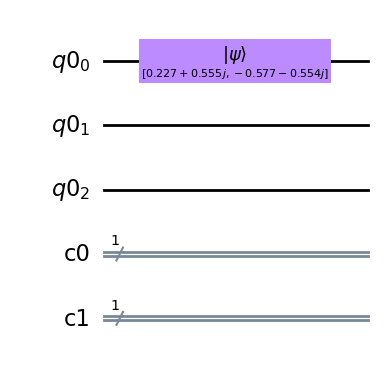

In [3]:
qr = QuantumRegister(3)    
cr1 = ClassicalRegister(1)
cr2 = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr1, cr2)
init_gate = Initialize(psi)
circuit.append(init_gate, [0])

circuit.draw(output="mpl")

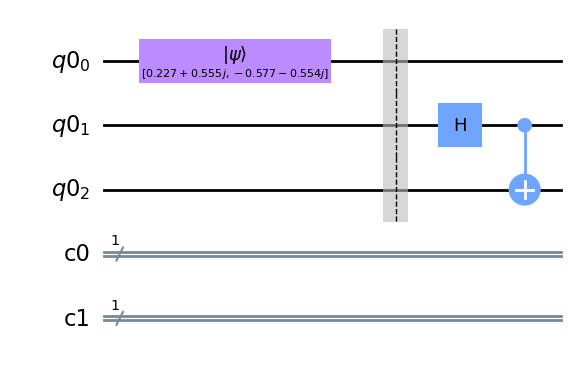

In [4]:
circuit.barrier()

circuit.h(1)
circuit.cx(1,2)
circuit.draw(output="mpl")

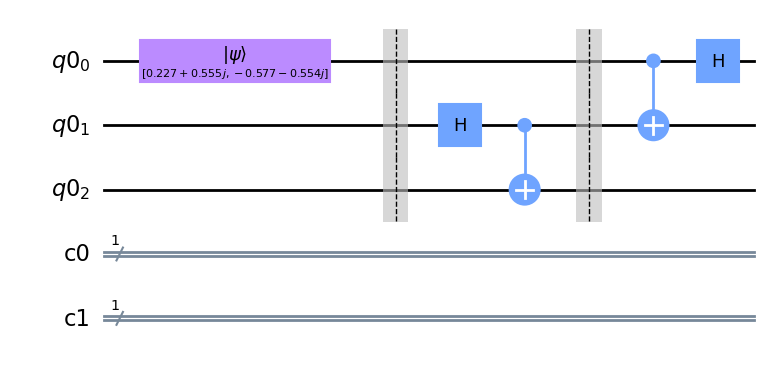

In [5]:
circuit.barrier()
circuit.cx(0,1)
circuit.h(0)
circuit.draw("mpl")

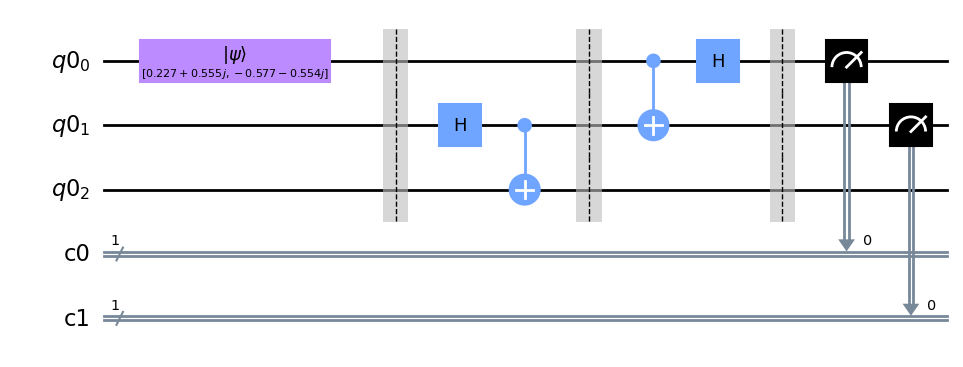

In [6]:
circuit.barrier()
circuit.measure([0,1],[cr1[0],cr2[0]])
circuit.draw("mpl")

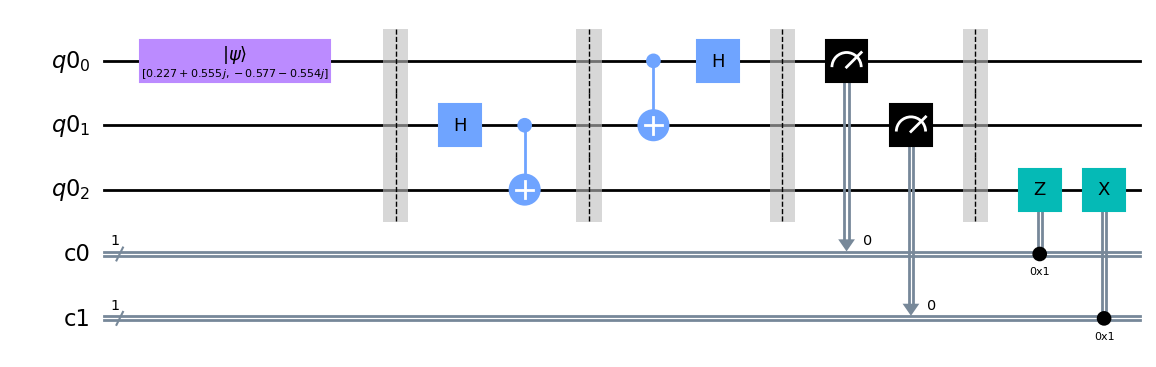

In [7]:
circuit.barrier()
circuit.z(2).c_if(cr1, 1)
circuit.x(2).c_if(cr2, 1)
circuit.draw("mpl")

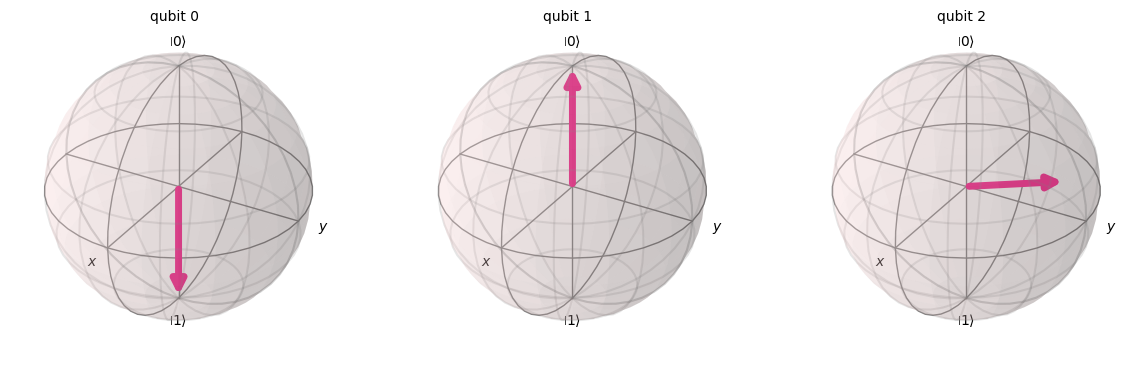

In [8]:
backend = BasicAer.get_backend('statevector_simulator')
out_vector = execute(circuit, backend).result().get_statevector()
plot_bloch_multivector(out_vector)

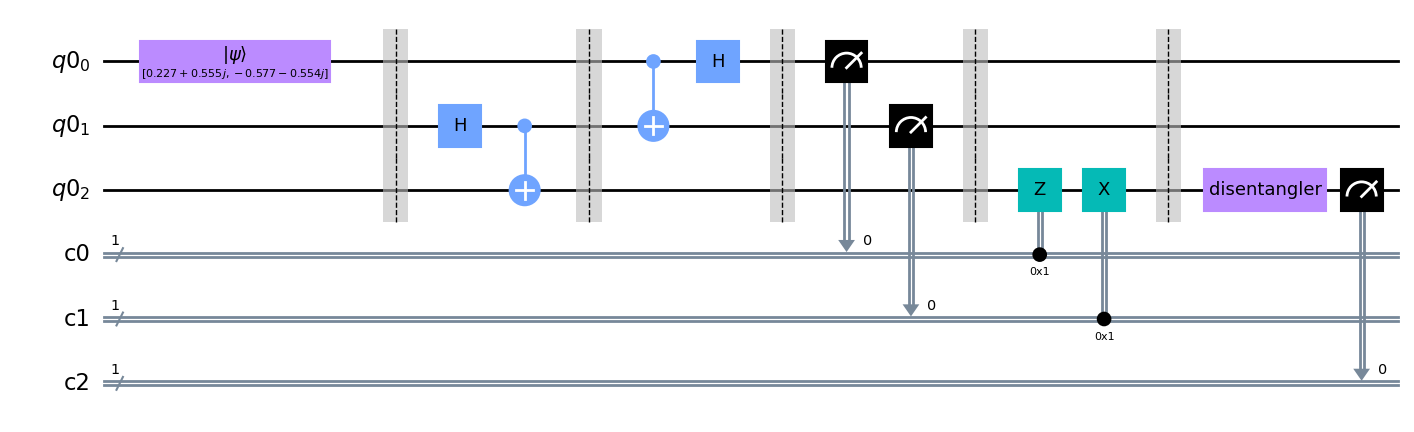

In [9]:
circuit.barrier()
inverse_init_gate = init_gate.gates_to_uncompute()
circuit.append(inverse_init_gate, [2])

cr_result = ClassicalRegister(1)
circuit.add_register(cr_result)
circuit.measure(2,2)

circuit.draw(output='mpl')

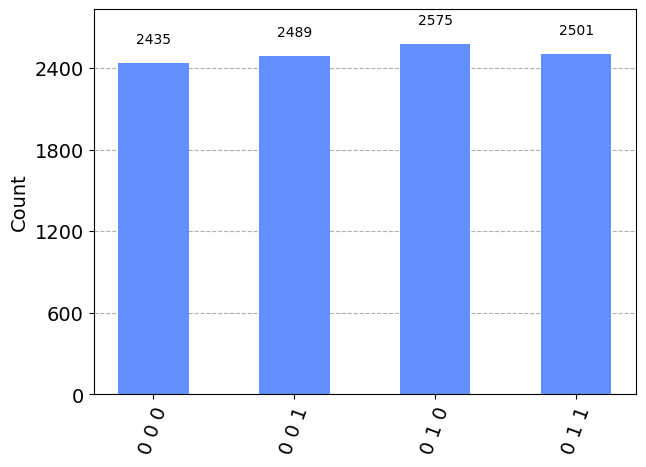

In [10]:
backend = BasicAer.get_backend('qasm_simulator')
counts = execute(circuit, backend, shots=10000).result().get_counts()
plot_histogram(counts)